# 02 — Model Training & Evaluation

Training **Random Forest** (supervised) + **Isolation Forest** (unsupervised anomaly detection).

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

df = pd.read_csv('../data/network_data.csv')
le = LabelEncoder()
df['protocol_encoded'] = le.fit_transform(df['protocol_type'])

FEATURES = ['duration','src_bytes','dst_bytes','count','srv_count',
            'same_srv_rate','diff_srv_rate','dst_host_count','dst_host_srv_count','protocol_encoded']

X = df[FEATURES]
y = (df['label']=='attack').astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [2]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['normal','attack']))

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       140
      attack       1.00      1.00      1.00        60

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



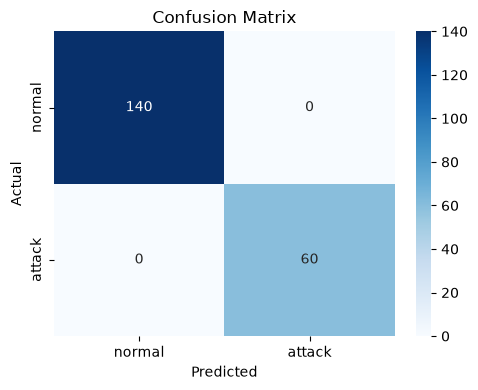

In [3]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['normal','attack'], yticklabels=['normal','attack'])
plt.title('Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

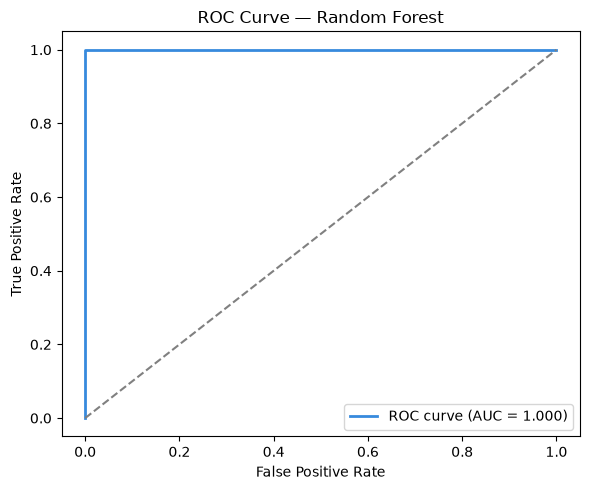

In [4]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='#378ADD', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

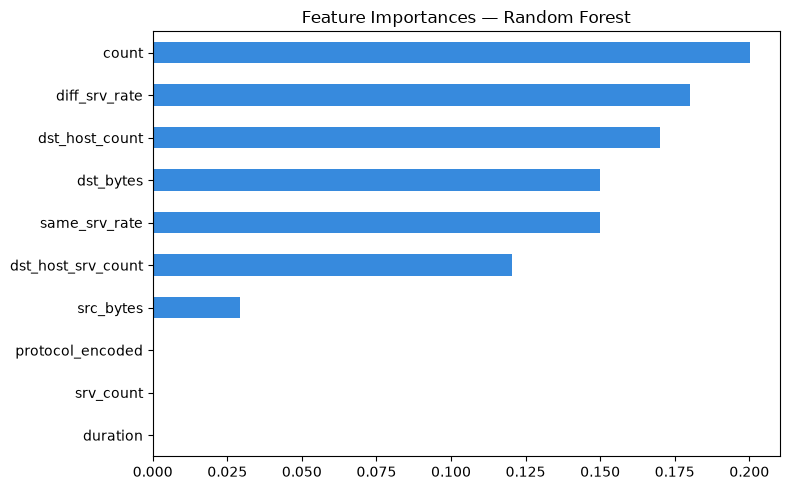

In [5]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='#378ADD')
plt.title('Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

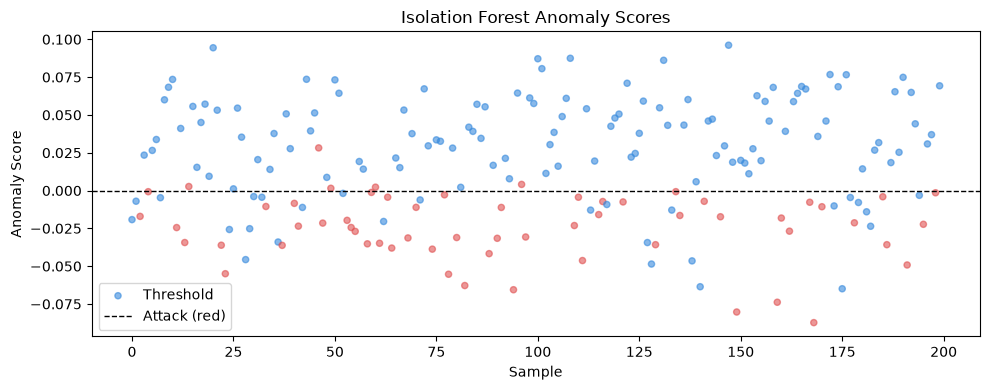

Lower score = more anomalous


In [6]:
# Isolation Forest
iso = IsolationForest(contamination=0.3, random_state=42)
iso.fit(X_train)
iso_scores = iso.decision_function(X_test)

plt.figure(figsize=(10,4))
colors = ['#E05252' if v==1 else '#378ADD' for v in y_test.values]
plt.scatter(range(len(iso_scores)), iso_scores, c=colors, alpha=0.6, s=20)
plt.axhline(0, color='black', linestyle='--', lw=1, label='Anomaly threshold')
plt.title('Isolation Forest Anomaly Scores')
plt.xlabel('Sample'); plt.ylabel('Anomaly Score')
plt.legend(['Threshold','Attack (red)','Normal (blue)'])
plt.tight_layout()
plt.show()
print('Lower score = more anomalous')